# Example Notebook: Core Image Processing

This is an example notebook to specify proper usage of the core image processing notebook used in our mother machine image<br>
processing pipeline. This pipline is ideal for Mother Machine image data where cells possess fluorescent segmentation markers.

The steps in this pipeline are as follows:
1. Extracting your Mother Machine data (.nd2) into hdf5 format
2. Identifying and cropping individual trenches into kymographs
3. Segmenting cells with a fluorescent marker
4. Determining lineages and object properties

In each step, the user will dynamically specify parameters using a series of interactive diagnostics on their dataset.<br>
Following this, a parameter file will be written to disk and then used to deploy a parallel computation on the <br>
dataset, either locally or on a SLURM cluster.

As pert of this pipeline, steps 1-2 are repeated on the MARLIN genotyping data, with a final section requiring the <br>
genotype to phenotype lookup table provided by the `marlin-nanopore` module. See examples of the sequencing analysis <br>
in the `Sequencing` folder.

Example data to run step 1 in this notebook are provided in the associated Zonodo repository `doi:10.5281/zenodo.14537796` at `\path\to\zenodo\Data\Example_Raw_Data\Mother_Machine`

#### Imports

Run this section to import all relavent packages and libraries used in this notebook. You must run this everytime you open a new python kernel.

In [3]:
import trenchripper as tr
import warnings
import dask
import matplotlib
import tifffile

from matplotlib import pyplot as plt

dask.config.set({'distributed.scheduler.active-memory-manager.start': True});
dask.config.set({'distributed.scheduler.worker-ttl': "5m"});
dask.config.set({'distributed.scheduler.allowed-failures': 100});

warnings.filterwarnings(action="once")
matplotlib.rcParams["figure.figsize"] = [20, 10]

## Set Path to Data Folder

- Also set `analysis_is_local` to `True` if working on a single machine or `False` if working on a `SLURM` cluster.
- If using a `SLURM` cluster, set `dask_workingdir` to your scratch path.

In [4]:
path_to_data = "./"
path_to_example_data = path_to_data + "Example_Raw_Data/Mother_Machine"
analysis_is_local = True
dask_workingdir = "./dask"

# Part 0: Flat Field Generation

If you have not done so, generate reference images, derived from imaging a uniform fluorescent sample (usually<br>
a dye solution spread on a coverslip). Use the following code to generate such composite images for use in the<br>
pipeline from sample images in ```.nd2``` format.

### Dark Image

In [5]:
flatfieldpath = path_to_example_data + "/20X_Dark.nd2"
outputpath = path_to_example_data + "/20X_Dark.tiff"
tr.generate_flatfield(flatfieldpath,outputpath)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/ndextract.py:56: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(outputpath,data=aggregated_img)


### mCherry

In [6]:
flatfieldpath = path_to_example_data + "/20X_mCherry.nd2"
outputpath = path_to_example_data + "/20X_mCherry.tiff"
tr.generate_flatfield(flatfieldpath,outputpath)

### Plot Reference Images

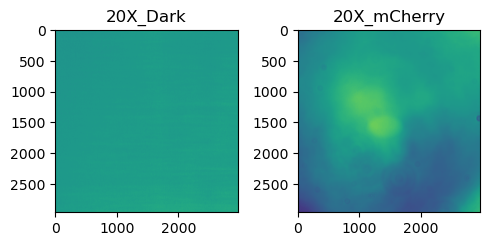

In [7]:
dark_outputpath = path_to_example_data + "/20X_Dark.tiff"
Mcherry_outputpath = path_to_example_data + "/20X_mCherry.tiff"

fflist = [dark_outputpath,Mcherry_outputpath]

fig, axs = plt.subplots(figsize=(5, 6), nrows= 1, ncols = 2)

for i in range(2):
    axs[i].imshow(tifffile.imread(fflist[i]))
    axs[i].set_title(fflist[i].split('/')[-1].split(".")[0])
plt.tight_layout()

# Part 1: Growth/Division

#### Specify Paths

Begin by defining the directory in which all processing will be done, as well as the initial nd2 file we will be <br>processing. This line should be run everytime you open a new python kernel.

The format should be: `headpath = "/path/to/folder"` and `nd2file = "/path/to/file.nd2"`

For example:
```
headpath = "/n/scratch2/de64/2019-05-31_validation_data"
nd2file = "/n/scratch2/de64/2019-05-31_validation_data/Main_Experiment.nd2"
```

Ideally, these files should be placed in a storage location with relatively fast read and write speed.

In [8]:
headpath = path_to_example_data + "/Growth_Division"
nd2file = path_to_example_data + "/Experiment_crop.nd2"

## Extract to hdf5 files

In this section, we will be extracting our image data. Currently this notebook only supports `.nd2` format; however <br>there are `.tiff` extractors in the TrenchRipper source files that can also be used.

In the abstract, this step will take a single `.nd2` file and split it into a set of `.hdf5` files stored in <br>`headpath/hdf5`. Splitting the file up in this way will facilitate quick procesing in later steps. Each field of <br>view will be split into one or more `.hdf5` files, depending on the number of images per file requested (more on <br>this later). 

To keep track of which output files correspond to which FOVs, as well as to keep track of experiment metadata, the <br>extractor also outputs a `metadata.hdf5` file in the `headpath` folder. The data from this step is accessible in <br>that `metadata.hdf5` file under the `global` key. If you would like to look at this metadata, you may use the <br>`tr.utils.pandas_hdf5_handler` to read from this file. Later steps will add additional metadata under different <br>keys into the `metadata.hdf5` file.

#### Start Dask Workers

First, we start a `dask_controller` instance which will handle all of our parallel processing. The default parameters <br>here work well on O2. The critical arguments here are:

**walltime** : For a cluster, the length of time you will request each node for.

**local** : `True` if you want to perform computation locally. `False` if you want to perform it on a SLURM cluster.

**n_workers** : Maximum number of nodes to request, will request if computation is triggered requiring many nodes.

**n_workers_min** : Number of nodes to immediately request.

**memory** : For a cluster, the amount of memory you will request each node for.

**working_directory** : For a cluster, the directory in which data will be spilled to disk. Usually set as a folder in <br>the `headpath`.

In [9]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

50m
1:00:00


#### Link to the Dask Dashboard

In [10]:
if analysis_is_local is False:
    dask_controller.displaydashboard()

##### Perform Extraction

Now that we have our cluster scheduler spun up, it is time to convert files. This will be handled by the <br>`hdf5_extractor` object. This extractor will pull up each FOV and split it such that each derived `.hdf5` file <br>contains, at maximum, N timepoints of that FOV per file. The image data stored in these files takes the <br>form of `(N,Y,X)` arrays that are accessible using the desired channel name as a key. 

The arguments for this extractor are:

 - **nd2file** : The filepath to the `.nd2` file you intend to extract.
 
 - **headpath** : The folder in which processing is occuring. Should be the same for each step in the pipeline.

 - **tpts_per_file** : The maximum number of timepoints stored in each output `.hdf5` file. Typical values are between 25 <br>and 100.

 - **ignore_fovmetadata** : Used when `.nd2` data is corrupted and does not possess records for stage positions or <br>timepoints. Only set `False` if the extractor throws errors on metadata handling.

In [11]:
hdf5_extractor = tr.ndextract.hdf5_fov_extractor(
    nd2file,
    headpath,
    tpts_per_file=50,
    ignore_fovmetadata=False,
)

##### Extraction Parameters

Here, you may set the time interval you want to extract. Useful for cropping data to the period exhibiting the dynamics of interest.

Optionally take notes to add to the `metadata.hdf5` file. Notes may also be taken directly in this notebook.

For this example, select `0` from the fov_list and press "Run Interact"

In [12]:
hdf5_extractor.inter_set_params()

/opt/conda/envs/app/lib/python3.11/site-packages/tables/path.py:137: NaturalNameWarning: object name is a Python keyword: 'global'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


interactive(children=(SelectMultiple(description='fov_list', options=(0,), value=()), IntRangeSlider(value=(0,…

#### List of paths to flat fields

Here, in each of the tabs, you may specify the path to each of the composite flat fielding images you generated in<br>
"Part 0". Make sure to put the path in quotation marks, otherwise it will not be interpreted correctly.

For this example, you may leave this blank

In [13]:
hdf5_extractor.inter_set_flatfieldpaths()

##### Begin Extraction 

Running the following line will start the extraction process. This may be monitored by examining the `Dask Dashboard` <br> under the link displayed earlier. Once the computation is complete, move to the next line.

In [14]:
hdf5_extractor.extract(dask_controller)

/opt/conda/envs/app/lib/python3.11/site-packages/tables/path.py:137: NaturalNameWarning: object name is a Python keyword: 'global'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
/opt/conda/envs/app/lib/python3.11/site-packages/tables/path.py:137: NaturalNameWarning: object name is a Python keyword: 'global'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


## Kymographs

Now that you have extracted your data into a series of `.hdf5` files, we will now perform identification and cropping <br>of the individual trenches/growth channels present in the images. This algorithm assumes that your growth trenches <br>are vertically aligned and that they alternate in their orientation from top to bottom. See the example image for the <br>correct geometry:

![example_image](resources/example_image.jpg)

The output of this step will be a set of `.hdf5` files stored in `headpath/kymograph`. The image data stored in these <br>files takes the form of `(K,T,Y,X)` arrays where K is the trench index, T is time, and Y,X are the crop dimensions. <br>These arrays are accessible using keys of the form `"[Image Channel]"`. For example, looking up phase channel <br>data of trenches in the topmost row of an image will require the key `"Phase"`

### Test Parameters



##### Initialize the interactive kymograph class

As a first step, initialize the `tr.interactive.kymograph_interactive` class that will be help us choose the <br>parameters we will use to generate kymographs. 

In [15]:
interactive_kymograph = tr.kymograph_interactive(headpath)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


You will now want to select a few test FOVs to try out parameters on, the channel you want to detect trenches on, and <br>
the time interval on which you will perform your processing.

The arguments for this step are:

- **seg_channel (string)** : The channel name that you would like to segment on.

- **filter_channel (string)** : Typically set to ```None```, specifies a fluorescence channel to compute a focus quality score <br>
and average fluorescence intensity for optional quality filter on lineage focus.

- **invert (list)** : Whether or not you want to invert the image before detecting trenches. By default, it is assumed that <br>
the trenches have a high pixel intensity relative to the background. This should be the case for Phase Contrast and <br>
Fluorescence Imageing, but may not be the case for Brightfield Imaging, in which case you will want to invert the image.

- **selected_fov_list (list)** : List of integers corresponding to the FOVs that you wish to make test kymographs of. Note that all<br>
lineages will be extracted during the full run.

- **t_subsample_step (int)** : Step size to be used for subsampling input files in time, recommend that subsampling results in <br>
between 5 and 10 timepoints for quick processing.

Hit the "Run Interact" button to lock in your parameters. The button will become transparent briefly and become solid again <br>
when processing is complete. After that has occured, move on to the next step. 

In [16]:
interactive_kymograph.import_hdf5_interactive()

interactive(children=(Dropdown(description='seg_channel', options=('mCherry',), value='mCherry'), Dropdown(des…

##### Tune "trench-row" detection hyperparameters

The kymograph code begins by detecting the positions of trench rows in the image as follows:

1. Reducing each 2D image to a 1D signal along the y-axis by computing the qth percentile of the data along the x-axis
2. Smooth this signal using a median kernel
3. Normalize the signal by linearly scaling 0. and 1. to the minimum and the qth percentile of the smoothed signal, respectively
4. Use a set threshold to determine the trench row poisitons

The arguments for this step are:

 - **y_percentile (int)** : Percentile to use for step 1.

 - **smoothing_kernel_y_dim_0 (int)** : Median kernel size to use for step 2.

 - **y_foreground_percentile (int)** : Percentile to use for step 3. The value should roughly correspond to the percentage<br>
 of the signal expected to be in the background (non-trench).
   
 - **y_percentile_threshold (float)** : Threshold to use in step 4.

Running the following widget will display the smoothed 1-D signal for each of your timepoints. In addition, the threshold <br>
value for each fov will be displayed as a red line.

In [17]:
interactive_kymograph.preview_y_precentiles_interactive()

interactive(children=(IntSlider(value=99, description='y_percentile'), IntSlider(value=80, description='y_fore…

##### Generate Trench Row Consensus (optional)

Acoording to the parameters from the previous step, the y-axis signal will be computed for <br>
a number of fields of view (FOVs) and averaged into a consensus signal, which specifies the standard<br>
positioning of each row of trenches in a standard FOV. Orientations for each of these rows can then<br>
be determined as specified in the next section. Later in kymograph extraction, this consensus<br>
will be used in cases where to infer row orientation in single FOVs, even when some rows are not detected.

The arguments for this step are:

 - **n_fovs (int)** : Number of random FOVs used to compute the trench row consensus.

 - **y_consensus_enabled (bool)** : Whether to turn on the use of a consensus reference. If disabled, FOVs<br>
 with less detected rows than the number of expected rows will be dropped.

In [16]:
interactive_kymograph.preview_y_precentiles_consensus_interactive()

interactive(children=(IntSlider(value=50, description='n_fovs', step=5), Dropdown(description='Y Consensus Ena…

##### Tune "trench-row" cropping hyperparameters

Next, we will use the detected rows to perform cropping of the input image in the y-dimension:

1. Determine edges of trench rows based on threshold mask.
2. Filter out rows that are too small.
3. Use the remaining rows to compute the drift in y in each image.
4. Apply the drift to the initally detected rows to get rows in all timepoints.
5. Perform cropping using the "end" of the row as reference (the end referring to the part of the trench farthest from <br>the feeding channel).

Additionally, if the device trenches face a single direction, alternation of row orientation may be turned off by setting the<br>
`Alternate Orientation?` argument to False. The `Use Median Drift?` argument, when set to True, will use the<br>
median drift in y across all FOVs for drift correction, instead of doing drift correction independently for all FOVs. <br>
This can be useful if there are a large fraction of FOVs which are failing drift correction. Note that `Use Median Drift?` <br>
sets this behavior for both y and x drift correction and will be overridden by the ```preview_kymographs_interactive``` method.

The arguments for this step are:

 - **y_min_edge_dist (int)** : Minimum row length necessary for detection (filters out small detected objects).

 - **midpoint_dist_tolerence (int)** : The maximum allowed distance between the detected trench midpoint (along the y-axis) and the <br>
 consensus-based midpoint from the previous step.

 - **padding_y (int)** : Padding to add to the end of trench row when cropping in the y-dimension.

 - **trench_len_y (int)** : Length from the end of each trench row to the feeding channel side of the crop.

 - **Number of Rows (int)** : The number of rows to expect in your image. For instance, two in the example image.
 
 - **Alternate Orientation? (bool)** : Whether or not to alternate the orientation of consecutive rows.

 - **Orientation (int)** : The orientation of the top-most row where 0 corresponds to a trench with a downward-oriented trench <br>opening and 1 corresponds to a trench with an upward-oriented trench opening.

 - **Alternate Orientation Over Rows? (bool)** : Whether or not to alternate the expected orientation of the top-most row, over<br>
 rows of FOVs in a regular grid. Used when the imaging grid is out of phase with the periodicity of trench orientation switching.

 
 - **Use Median Drift? (bool)** : Whether to use the median detected drift across all FOVs, instead of the drift detected in each FOV individually.

 - **images_per_row(int)** : How many images to output per row for this widget.

Running the following widget will display y-cropped images for each fov and timepoint.

In [18]:
interactive_kymograph.preview_y_crop_interactive()

interactive(children=(IntSlider(value=50, description='y_min_edge_dist', max=1000, min=5, step=5), IntSlider(v…

##### Tune trench detection hyperparameters

Next, we will detect the positions of trenchs in the y-cropped images as follows:

1. Reducing each 2D image to a 1D signal along the x-axis by computing the qth percentile of the data along the y-axis.
2. Determine the signal background by smoothing this signal using a large median kernel.
3. Subtract the background signal.
4. Smooth the resultant signal using a median kernel.
5. Use a threshold on the resulting signal, optionally compositing this with an [otsu threhsold](https://imagej.net/Auto_Threshold#Otsu), to determine the trench midpoint poisitons.

After this, x-dimension drift correction of our detected midpoints will be performed as follows:

6. Begin at t=1
7. For $m \in \{midpoints(t)\}$ assign $n \in \{midpoints(t-1)\}$ to m if n is the closest midpoint to m at time $t-1$,<br>
points that are not the closest midpoint to any midpoints in m will not be mapped.
8. Compute the translation of each midpoint at time.
9. Take the average of this value as the x-dimension drift from time t-1 to t.

The arguments for this step are:

 - **t (int)** : Timepoint to examine the percentiles and threshold in.

 - **x_percentile (int)** : Percentile to use for step 1.

 - **background_kernel_x (int)** : Median kernel size to use for step 2.

 - **smoothing_kernel_x (int)** : Median kernel size to use for step 4.

 - **otsu_scaling (float)** : Scaling factor to apply to the threshold determined by Otsu's method in step 5.

 - **min_threshold (int)** : Simple theshold to apply in step 5.

Running the following widget will display the smoothed 1-D signal for each of your timepoints. In addition, the threshold <br>value for each fov will be displayed as a red line. In addition, it will display the detected midpoints for each of your timepoints. <br>If there is too much sparsity, or discontinuity, your drift correction will not be accurate.

In [19]:
interactive_kymograph.preview_x_percentiles_interactive()

interactive(children=(IntSlider(value=0, description='t', max=16), IntSlider(value=85, description='x_percenti…

##### Tune trench cropping hyperparameters

Trench cropping simply uses the drift-corrected midpoints as a reference and crops out some fixed length around them <br>
to produce an output kymograph.

The arguments for this step are:

 - **trench_width_x (int)** : Trench width to use for cropping.

 - **trench_present_thr (float)** : Trenches that appear in less than this percent of FOVs will be eliminated from the dataset.<br>
If not removed, missing positions will be inferred from the image drift.

 - **Use Median Drift? (bool)** : Whether to use the median detected drift across all FOVs, instead of the drift detected in each FOV individually.<br>
 Note that this overrides the selection of "Use Median Drift?" in the "preview_y_precentiles_consensus_interactive" method.


Running the following widget will display a random kymograph for each row in each fov and will also produce midpoint plots <br>showing retained midpoints.

In [20]:
interactive_kymograph.preview_kymographs_interactive()

interactive(children=(IntSlider(value=30, description='trench_width_x', max=1000, min=2, step=2), FloatSlider(…

##### Export and save hyperparameters

Run the following line to register and display the parameters you have selected for kymograph creation.

In [21]:
interactive_kymograph.process_results()

Y Percentile 99
Y Foreground Percentile 80
Y Smoothing Kernel 29
Y Percentile Threshold 0.2
Minimum Trench Length 50
Midpoint Distance Tolerance 50
Y Padding 20
Trench Length 270
Orientation Detection Method 1
Expected Number of Rows (Manual Orientation Detection) 10
Alternate Orientation True
Alternate Orientation Over Rows? False
Use Median Drift? False
Consensus Orientations None
Consensus Midpoints None
X Percentile 85
X Background Kernel 21
X Smoothing Kernel 9
Otsu Threshold Scaling 0.25
Minimum X Threshold 0
Trench Width 30
Trench Presence Threshold 0.0
All Channels ['mCherry']
Filter Channel None
Invert False


If you are satisfied with the above parameters, run the following line to write these parameters to disk at `headpath/kymograph.par`<br>
This file will be used to perform kymograph creation in the next section.

In [ ]:
interactive_kymograph.write_param_file()

### Generate Kymograph

##### Perform Kymograph Cropping

In this step we run the full (non-interactive) kymograph generation for the dataset. The kymograph cropper will:

1. Read the extracted movies in `headpath/hdf5/` (created in the extraction step).

2. Detect trench rows in Y, then detect individual trenches in X.

3. Write per-trench kymographs to `headpath/kymograph/` as .hdf5 files containing arrays shaped (K, T, Y, X), where K is trench index and T is time.

Note that this step overwrites the existing `headpath/kymograph/` folder (including temporary outputs). If you want to keep an older kymograph run, rename or move that folder first.

By default, we run using the parameters you tuned interactively and saved to disk at `headpath/kymograph.par` (via `interactive_kymograph.write_param_file()`). 

##### Begin Kymograph Cropping 

Running the following line will start the cropping process. This may be monitored by examining the `Dask Dashboard` <br>
under the link displayed earlier. Once the computation is complete, move to the next line.

**Do not move on until all tasks are displayed as 'in memory' in Dask or the kernel is idle**

In [19]:
kymoclust = tr.kymograph.kymograph_cluster(
    headpath=headpath, paramfile=True
)

In [21]:
kymoclust.generate_kymographs(dask_controller)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
2026-01-05 12:25:22,072 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.62 GiB -- Worker memory limit: 3.73 GiB
2026-01-05 12:25:22,369 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.63 GiB -- Worker memory limit: 3.73 GiB
202

##### Filter Out Out of Focus Lineages (Optional) 

**Skip the next 4 lines of code if you don't have a filter channel**

This step is an optional **quality-control filter** that removes entire trench lineages (`trenchid`) that are frequently **out of focus** and/or **too dim** in a chosen fluorescence channel.

A few implementation details to keep in mind:

- The filter is applied at the **trenchid level** (i.e., you keep or discard an entire lineage), not frame-by-frame.
- Each timepoint is labeled “good” if it passes **both** a focus threshold and an intensity threshold.
- A trenchid is kept if it has enough “good” timepoints, controlled by the *Percent Of Kymograph* setting (`perc_above_thr`).
- If you select `channel = None`, filtering is effectively disabled (the rest of the notebook can proceed normally).

Recommended workflow:

1. **Select the channel to filter on** using the dropdown from `ff.choose_filter_channel_inter()`.
   - In most cases, pick the same fluorescence channel you used for `filter_channel` during kymograph generation.

2. **Inspect score distributions** with `ff.plot_histograms(...)`.
   - This plots the distribution of the per-timepoint *Focus Score* and *Mean Intensity* so you can choose reasonable cutoffs.

3. **Tune thresholds visually** with `ff.plot_focus_threshold_inter()`.
   - The widget shows example trench images “Above Threshold” and “Below Threshold” to help you validate your choices.

The interactive threshold widget controls:

- **focus_thr** (float): Minimum focus score for a timepoint to count as “good”.
- **intensity_thr** (int): Minimum mean intensity for a timepoint to count as “good”.
- **perc_above_thr** (float, 0–1): Fraction of timepoints that must be “good” for the trenchid to be kept.
  - Tip: If you sometimes have brief focus slips, try `perc_above_thr < 1.0` instead of tightening `focus_thr`.
- **n_images** (int): Number of example images to display for the “Above/Below Threshold” preview.

Finally, run `ff.write_param_file()` to save your selections. These parameters are written to `focus_filter.par` and will be applied during the **Post-process Images** step.


In [22]:
ff = tr.focus_filter(headpath)
ff.choose_filter_channel_inter()

interactive(children=(Dropdown(description='channel', options=(None,), value=None), Button(description='Run In…

In [23]:
ff.plot_histograms(intensity_range=(0,1500))

TypeError: unsupported operand type(s) for +: 'NoneType' and 'str'

In [24]:
ff.plot_focus_threshold_inter()

No Channel Selected


In [25]:
ff.write_param_file()

##### Remove Lanes (Optional)

This optional QC step lets you **exclude compromised lanes** (implemented as **Global Rows** in the full-chip grid) before downstream processing. This is most useful when one or more lanes are affected b**biofil**, debris, bubbles, or other artifacts that would otherwise generate poor kymographs.

How it works:

- `tr.lane_overlay(...)` renders a **whole-chip overlay** where each lane/global-row is shown as a selectable rectangle.
- You **select the rows you want to eliminate** directly on the overlay output (click/box-select the problematic lanes).
- `lane_overlay_handle.save_rows()` then saves the set of *rows to keep* to:
  - `kymograph/global_rows.pkl`

Downstream behavior:

- If `kymograph/global_rows.pkl` exists, later post-processing will automatically **filter metadata to only the kept Global Rows**, effectively removing the excluded lanes from the remainder of the pipeline.

Notes / constraints:

- **Only works with full grids.** This method relies on the dataset having valid grid indexing so that a “Global Row” can be assigned consistently across the chip.

Display controls:

- `view_overlay(size=..., vmin=..., vmax=...)` can be used to adjust the rendered overlay size and intensity scaling.

Then use `lane_overlay_handle.save_rows()` to update which rows to keep for analysis.acts easier to spot.
acts easier to spot.


In [ ]:
lane_overlay_handle = tr.lane_overlay(headpath,persist_data=True)
overlay = lane_overlay_handle.view_overlay(size=2500,vmin=0,vmax=4000)

In [ ]:
overlay

In [ ]:
lane_overlay_handle.save_rows()

##### Post-process Images

After the previous step, kymographs have been generated for each input `.hdf5` file. In practice, those per-input files are usually **not the most convenient unit for downstream segmentation/tracking**, so this step **repackages** the kymographs into a new set of output files with a controlled size.

This is also the point where any optional *lineage- or lane-level QC decisions* you made earlier get applied:

- If `focus_filter.par` exists (written by the focus-filter widget), out-of-focus / dim **trench lineages** may be removed here.
- If `kymograph/global_rows.pkl` exists (written by the lane-removal overlay), excluded **lanes/global rows** will be removed here.

The main size-control parameter is:

- **trench_timepoints_per_file** : Maximum number of *(trench × timepoint)* entries stored in each output `.hdf5` file.
  - Internally, this is converted into an approximate **trenches-per-file** limit by dividing by the number of timepoints per trench.
  - Typical values are on the order of `10000` (adjust upward for fewer/larger files, downward for more/smaller files).

Run the post-processing step with:

`kymoclust.post_process(dask_controller, trench_timepoints_per_file=...)`

**Do not move on until all tasks are displayed as 'in memory' in Dask or the kernel is idle**


In [29]:
kymoclust.post_process(dask_controller,trench_timepoints_per_file=10000)

Applying Focus Filter...
Number of timepoints per trench: 165
Number of trenches per file: 60


/opt/conda/envs/app/lib/python3.11/site-packages/dask/dataframe/core.py:7365: FutureWarning: Meta is not valid, `map_partitions` and `map_overlap` expects output to be a pandas object. Try passing a pandas object as meta or a dict or tuple representing the (name, dtype) of the columns. In the future the meta you passed will not work.
  warnings.warn(
/opt/conda/envs/app/lib/python3.11/site-packages/dask/dataframe/io/parquet/core.py:1241: FutureWarning: The fastparquet engine is deprecated and will be removed in a future release. Please install pyarrow.
  warnings.warn(
/opt/conda/envs/app/lib/python3.11/site-packages/dask/base.py:1525: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(
/opt/conda/envs/app/lib/python3.11/site-packages/dask/base.py:1525: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(
/opt/conda/e

##### Check kymograph statistics

Run the next line to print a quick **sanity-check report** for kymograph creation:

- **fovs processed** : How many FOVs produced usable kymographs (out of the total attempted).
- **rows processed** : Total number of trench rows detected across all processed FOVs.
- **trenches processed** : Total number of individual trenches extracted across all processed FOVs.
- **row/fov** : Average number of rows per successfully processed FOV.
- **trenches/fov** : Average number of trenches per successfully processed FOV.
- **failed fovs** : A list of FOV indices that failed during processing.

If `failed fovs` is non-empty, it’s worth **spot-checking a few of those FOVs in the viewer** to identify common issues (e.g., missing/poor trench detection, major debris/bubbles, severe drift). If many FOVs fail, revisit earlier trench/lane/cropping parameters before moving on.



In [30]:
kymoclust.kymo_report()

fovs processed: 1/1
rows processed: 10
trenches processed: 1583
row/fov: 10.0
trenches/fov: 1583.0
failed fovs: []


## Fluorescence Segmentation

Now that you have copped your data into kymographs, we will now perform segmentation/cell detection <br>
on your kymographs. Currently, this pipeline only supports segmentation of fluorescence images; however, <br>
segmentation of transmitted light imaging techniques is in development.

The output of this step will be a set of `segmentation_[File #].hdf5` files stored in `headpath/fluorsegmentation`.<br>
The image data stored in these files takes the exact same form as the kymograph data, `(K,T,Y,X)` arrays <br>
where K is the trench index, T is time, and Y,X are the crop dimensions. These arrays are accessible using <br>
keys of the form `"[Trench Row Number]"`.

Since no metadata is generated by this step, it is possible to use another segmentation algorithm on the kymograph <br>
data. The output of segmentation must be split into `segmentation_[File #].hdf5` files, where `[File #]` agrees with the<br>
corresponding `kymograph_[File #].hdf5` file. Additionally, the `(K,T,Y,X)` arrays must be of the same shape as the <br>
kymograph arrays and accessible at the corresponding `"[Trench Row Number]"` key. These files must be placed into <br>
their own folder at `headpath/foldername`. This folder may then be used in later steps.

##### Initialize the interactive segmentation class

Start by creating an instance of the interactive fluorescence segmentation helper. This object will:

- Discover the available kymograph channels for this dataset
- Load the kymograph index/metadata needed for interactive previews
- Provide the widgets used below to choose a segmentation channel, preview preprocessing/thresholding, and finalize settings

Nothing is segmented at this point — you’re just initializing the interface. After tuning parameters, interactive_segmentation.write_param_file() will write your chosen settings to fluorescent_segmentation.par for use during the batch segmentation run.

In [31]:
interactive_segmentation = tr.fluo_segmentation_interactive(headpath)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


##### Choose channel to segment on

In [32]:
interactive_segmentation.choose_seg_channel_inter()

interactive(children=(Dropdown(description='seg_channel', options=('mCherry',), value='mCherry'), Dropdown(des…

#### Import data

Before tuning any segmentation parameters, we first **load a small, representative subset of kymographs** into memory for interactive preview. This subset is what all downstream interactive plots in this section will operate on, so it’s worth choosing something that captures the typical variability in your dataset (good trenches, dim trenches, occasional debris, etc.).

Running `interactive_segmentation.import_array_inter()` opens a widget that:

- Randomly selects `n_trenches` trench lineages from across the dataset
- Loads the chosen fluorescence `seg_channel` kymographs for a specified `t_range`
- Optionally subsamples timepoints to keep previews responsive

The key controls are:

- **n_trenches** : Number of trenches to load for interactive tuning.

- **t_range** : Timepoints to import for preview.

- **t_subsample_step** : Subsample factor along time (e.g., `2` loads every other frame). Useful for long timeseries.

Display/layout controls (do not affect the underlying data):

- **fig_size_y / fig_size_x** : Size of the rendered figure.
- **img_per_row** : How many trench previews to show per row.

After selecting settings, click the widget’s **Run** button to import and display the preview kymographs. These imported kymographs are then reused by the next interactive steps (processing and mask tuning) below.


In [33]:
interactive_segmentation.import_array_inter()

interactive(children=(IntText(value=12, description='Number of trenches:'), IntRangeSlider(value=(0, 164), des…

##### Process data

In this step we apply a lightweight **preprocessing pipeline** to the imported kymographs to make downstream thresholding and watershed segmentation more robust. The goal is not to “perfectly” normalize the images, but to (i) put intensities onto a consistent 8-bit scale, and (ii) reduce high-frequency noise so cell boundaries are easier to detect.

`interactive_segmentation.plot_processed_inter()` opens a manual widget that lets you tune the preprocessing parameters and preview the result. After you click **Run**, the processed kymographs are stored inside the interactive object and used by the mask-tuning widgets below.

Parameters you will tune here:

- **bit_max** (“8-bit Maximum”): Reference intensity used for converting the raw data to an 8-bit image. A histogram is shown (and the 99th percentile is printed) to help you pick a reasonable value.

- **scale_timepoints** (“Scale Fluorescence?”): If `True`, each timepoint is scaled so that a chosen percentile intensity is comparable across time. This can help with **photobleaching / illumination drift**, but it can also reduce real biological intensity changes. This is generally not used.

- **scaling_percentile** (“Scaling Percentile”): Percentile (0–100) used when `scale_timepoints=True`.

- **img_scaling** (“Image Upsampling Factor”): Upsamples the unwrapped kymograph before segmentation. This can make boundaries smoother/easier to separate, at the cost of speed and memory. Start with `1.0` and only increase if needed.

- **smooth_sigma** (“Gaussian Kernel Sigma”): Standard deviation for Gaussian smoothing. Increasing this reduces noise but can also blur thin features; values around `0.5–1.5` are usually a good starting range.

Once the processed images look reasonable (and the histogram scaling isn’t obviously over/under-stretching), move on to the mask-tuning widgets below.


In [34]:
interactive_segmentation.plot_processed_inter()

interactive(children=(IntSlider(value=1000, description='8-bit Maximum:', max=65535, step=250), Dropdown(descr…

#### Determine Cell Mask Envelope

In the next two interactive steps you will define a **coarse “envelope” mask** that roughly segments cells in each kymograph, plus an additional **Hessian-based mask** that highlights cell boundaries for separating touching cells later on.

##### 1) Tune the cell envelope mask

Run `interactive_segmentation.plot_cell_mask_inter()` and adjust:

- **local_thr**: Local threshold method (`"otsu"`, `"niblack"`, or `"none"`).

- **background_thr**: Background threshold method (`"triangle"`, `"yen"`, `"object-based"`, or `"none"`).

- **global_threshold**: A coarse intensity cutoff (shown on the histogram) used as a global gate.

- **window_size**: Neighborhood size for local thresholding.

- **cell_otsu_scaling**: Scaling applied to the (local) Otsu threshold (controls strictness).

- **niblack_k**: Niblack “k” parameter (controls strictness when `local_thr="niblack"`).

- **background_scaling**: Scaling applied to the background threshold method (controls strictness).

- **min_obj_size**: Minimum segment size to remain included.



In [35]:
interactive_segmentation.plot_cell_mask_inter()

interactive(children=(Dropdown(description='local_thr', options=('otsu', 'niblack', 'none'), value='otsu'), Dr…

##### 2) Then run `interactive_segmentation.plot_eig_mask_inter()` and adjust:

- **eig_local_thr** : Local threshold method for the Hessian image (`"otsu"` or `"niblack"`).

- **eig_sigma** : Gaussian blur sigma applied before thresholding (smooths noise vs. detail).

- **eig_window_size** : Neighborhood size for the local threshold.

- **eig_ball_radius** : Rolling-ball radius used for background subtraction on the Hessian-derived image.

- **eig_otsu_scaling** : Scaling applied to the local Otsu threshold (controls strictness when `eig_local_thr="otsu"`).

- **eig_niblack_k** : Niblack “k” parameter (controls strictness when `eig_local_thr="niblack"`).

Once both masks look reasonable on the preview trenches, you can proceed to batch segmentation.

In [36]:
interactive_segmentation.plot_eig_mask_inter()

interactive(children=(FloatSlider(value=2.0, description='Hessian Blur Sigma:', max=5.0, step=0.25), IntSlider…

Before generating final watershed markers, we construct a simple **interior mask** from the cell-envelope mask using a **distance transform**.

`interactive_segmentation.plot_dist_mask_inter()` computes, for each imported kymograph:

1. A distance image where each pixel value is its distance (in pixels) to the nearest **background** pixel of the cell envelope.
2. A binary mask that keeps only pixels that are **at least** `distance_threshold` pixels *inside* the envelope.

Tuning notes:

- **distance_threshold** (“Distance Threshold”) controls how aggressively you restrict to the **cellogic later.

The widget will display both the **distance image** and the resulting **thresholded interior mask** so you can quickly sanity-check that each cell still has a reasonable “core” region.


In [38]:
interactive_segmentation.plot_dist_mask_inter()

interactive(children=(IntSlider(value=2, description='Distance Threshold:', max=20), Button(description='Run I…

At this point we have two complementary binary masks:

- A **cell envelope** that defines the region where cells are allowed.
- An **interior/feature mask** (from the Hessian/eigen step + distance thresholding) that indicates cell cores to seed a final watershed step.

Next we combine these to create **watershed markers** (seeds) and generate the first-pass **labeled cell masks**. In `interactive_segmentation.plot_marker_mask_inter()`, the distance-transform “core” mask is multiplied by the Hessian-based mask to produce discrete marker regions, and these markers are then used to watershed within the cell envelope.

New parameters in this widget:

- **border_buffer** (Border Buffer): clears any segmented objects that touch the kymograph crop boundary.
  - Set to `-1` to **disable** border clearing.
  - Use `0` to drop objects that touch the border exactly; increase (`1–5`, etc.) to be more aggressive if you see frequent partial cells/artefacts on the crop edges.
- **horizontal_border_only**: Enable if you only want to clear objects touching the **top/bottom** boundaries rather than all four edges.

In [41]:
interactive_segmentation.plot_marker_mask_inter()

interactive(children=(FloatSlider(value=2.0, description='Hessian Blur Sigma:', max=5.0, step=0.25), IntSlider…

Once the marker-based preview looks reasonable, run `interactive_segmentation.process_results()` to **finalize and print** a concise summary of the settings you’ve chosen across all of the interactive widgets (processing, envelope masks, distance transform, and marker/watershed settings).


In [42]:
interactive_segmentation.process_results()

Extra Mask Path: None
8 Bit Maximum: 1000
Scale Fluorescence? False
Scaling Percentile: 90
Image Scaling Factor: 1.0
Gaussian Kernel Sigma: 0.75
Local Threshold Method: otsu
Background Threshold Method: triangle
Global Threshold: 50
Local Window Size: 15
Otsu Scaling: 0.9999999999999999
Niblack K: 0.2
Background Threshold Scaling: 1.0
Minimum Object Size: 30
Distance Threshold: 2
Hessian Blur Sigma: 2.0
Hessian Rolling Ball Size: 20
Hessian Local Threshold Method: niblack
Hessian Otsu Scaling: 0.9999999999999999
Hessian Niblack K: 0.05
Hessian Local Window Size: 7
Segmentation Channel: mCherry


If everything in the printed parameter summary looks correct, save the configuration to disk so it can be reused for the full batch run.

`interactive_segmentation.write_param_file()` writes a parameter file named:

- `fluorescent_segmentation.par`

In [ ]:
interactive_segmentation.write_param_file()

In [46]:
dask_controller.shutdown()

Done.


2023-01-16 15:06:18,012 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


### Generate Segmentation

#### Start Dask Workers

In [ ]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

In [ ]:
dask_controller.displaydashboard()

Now that your Dask workers are running, initialize the **batch fluorescence segmentation** object. This object loads the kymograph metadata and prepares the segmentation configuration that will be applied across the full dataset.

Because we saved parameters in the previous step, we set `paramfile=True` so the class will automatically read:

- `headpath/fluorescent_segmentation.par`

for the full run of the rest of the data.

In [43]:
segment = tr.segment.fluo_segmentation_cluster(headpath, paramfile=True)

In [44]:
segment.dask_segment(dask_controller)

Done.


#### Stop Dask Workers

In [ ]:
dask_controller.shutdown()

## Lineage Tracing

The next major stage is to convert the per-frame **segmentation masks** into consistent **cell lineages** through time.

Up to this point, each kymograph timepoint has an independent labeled mask (cell labels can appear/disappear, split, or change IDs arbitrarily). **Lineage tracing** solves the “identity problem” by linking segmented objects across time within each trench, handling **cell divisions**, and producing a single table of tracked cells that can be used for downstream measurements and visualization.

**Inputs**
- Kymograph metadata (trench/timepoint indexing)
- Fluorescence segmentation masks from the previous section (the `segmentation_[File Index].hdf5` files)

**Outputs**
- A lineage/tracking table written under `headpath/lineage/` (this is what later steps use to compute single-cell fluorescence/size/time traces).

In the following section you’ll (i) initialize the lineage tracing class, (ii) tune/inspect tracking behavior on a small subset if needed, and (iii) run the full tracing job across all files with Dask.


### Test Parameters


#### What each argument is doing

- **headpath** - Base analysis directory (used to locate segmentation outputs and metadata).

- **"fluorsegmentation"** - Name of the segmentation subfolder under `headpath/` to track (i.e., the objects whose regionprops will be scored).

- **size_attr="axis_major_length"** - Regionprop treated as the “size” feature when comparing objects across frames (here, major-axis length of each labeled object).

#### Size-change model

These parameters encode how much you expect the `size_attr` to change between adjacent timepoints:

- **u_size** - Expected *fractional* change in size per frame.

- **sig_size** - Tolerance (spread) around that expected change; smaller values make the tracker stricter about size deviations.

#### Position-change model

These parameters encode how much you expect a cell’s centroid to move between frames (in the tracker’s internal normalized coordinates):

- **u_pos** - Expected *fractional* displacement per frame.

- **sig_pos** - Tolerance (spread) around that expected displacement; smaller values make the tracker stricter about motion deviations.

#### Defunct Parameter

- **w_merge** - Extra weighting/penalty applied to **merge** hypotheses. Not currently functional.

In [47]:
score_function = tr.tracking.scorefn(
    headpath,
    "fluorsegmentation",
    size_attr='axis_major_length',
    u_size=0.08,
    sig_size=0.03,
    u_pos=0.1,
    sig_pos=0.05,
    w_merge=0.,
)

score_function.interactive_scorefn()

interactive(children=(IntSlider(value=0, description='trenchid', max=1582), IntRangeSlider(value=(0, 164), con…

In [48]:
Tracking_Solver = tr.tracking.tracking_solver(
    headpath, "fluorsegmentation", ScoreFn=score_function, edge_limit=2,
)
data, orientation = score_function.output.result

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


Before launching batch lineage tracing, it’s useful to **sanity-check the tracker interactively** on a small subset of trenches/timepoints.

The widget that opens from this call also lets you adjust a few practical display / search settings:

- **t_range**: Which timepoints to visualize in the overlay

- **edge_limit**: How many nearest candidate matches to consider per object

- **viewpadding**, **x_size**, **y_size**, **dot_size**: Visualization controls only (do not change the underlying tracking)

Run the interactive preview with:


In [49]:
Tracking_Solver.interactive_tracking(data, orientation)

interactive(children=(SelectMultiple(description='intensity_channel_list', options=('mCherry',), value=()), In…

Save the configuration to disk so it can be reused for the full batch run.

`Tracking_Solver.save_params()` writes a parameter file named:

- `lineage_tracing.par`

In [ ]:
# Tracking_Solver.save_params()

### Generate Lineage Traces

In [ ]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

In [ ]:
dask_controller.displaydashboard()

Once you’re satisfied with the interactive preview, initialize the full tracking solver that will be used for the **batch lineage-tracing run**.

This constructor does two things:

1. Loads the segmentation outputs from the folder you specify (here, `"fluorsegmentation"`).
2. Defines **which per-object properties** will be measured from each mask (geometry + intensity), including any unit conversions.

Notes on the key arguments:

- **paramfile=True** - Reads tracking parameters from the saved parameter file.

- **size_estimation=True** - Enables size estimation.

- **size_estimation_method** - Controls the method of size estimation is used.

- **props_list** - Controls which `skimage.measure.regionprops`-style geometric properties are computed from each labeled mask.

- **pixel_scaling_factors** - Applies a simple scaling to convert pixel units into physical units.

- **intensity_props_list** - Controls which `skimage.measure.regionprops`-style intensity properties are computed from each labeled mask.

In [50]:
Tracking_Solver = tr.tracking.tracking_solver(
    headpath, 
    "fluorsegmentation", 
    paramfile=True, 
    size_estimation=True,
    size_estimation_method='Perimeter/Area',
    props_list=['area'], 
    props_to_unpack={},
    pixel_scaling_factors={'area': 2},
    intensity_props_list=['mean_intensity'] 
)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


With the solver configured, you can now run **batch lineage tracing** across the full dataset. This step will:

- Iterate through all segmented kymograph files in `headpath/fluorsegmentation/`
- Compute per-object properties (e.g. `area`, `mean_intensity`)
- Link objects across time to build **lineages**, including handling divisions
- Write the resulting lineage/tracking tables under `headpath/lineage` for downstream analysis

Set `overwrite=False` to avoid recomputing results if lineage files already exist.

Launch the computation:

In [51]:
Tracking_Solver.compute_all_lineages(dask_controller,entries_per_partition = 100000, overwrite=False)

Kymograph files per partition: 11


/opt/conda/envs/app/lib/python3.11/site-packages/dask/base.py:1525: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/conda/envs/app/lib/python3.11/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/9292a09ad726404fa395d215dea74478-pulp.mps -mips /tmp/9292a09ad726404fa395d215dea74478-pulp.mst -timeMode elapsed -branch -printingOptions all -solution /tmp/9292a09ad726404fa395d215dea74478-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3924 COLUMNS
At line 40671 RHS
At line 44591 BOUNDS
At line 49848 ENDATA
Problem MODEL has 3919 rows, 5256 columns and 35612 elements
Coin0008I MODEL read with 0 errors
opening mipstart file /tmp/9292a09ad726404fa395d215dea74478-pulp.mst.
MIPStart values read for 5256 variables.
Option for timeMode changed from cpu to elapsed
Presolve 3879 (-40) rows, 5227 (-29) columns and 35474 (-138) elements
Perturbing problem by 0.001% of 124.62986 - largest nonzero change 0.00099954257 ( 0.006457633%) - largest zero change 0.00099908714
0  Obj 0 Dual inf 1

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/metrics.py:71: RuntimeWarning: invalid value encountered in sqrt
  width = (perimeter-np.sqrt(perimeter**2 - 4*np.pi*area))/np.pi


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/conda/envs/app/lib/python3.11/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/fa8043ff94c84c0ab8f37c14ff451f8d-pulp.mps -mips /tmp/fa8043ff94c84c0ab8f37c14ff451f8d-pulp.mst -timeMode elapsed -branch -printingOptions all -solution /tmp/fa8043ff94c84c0ab8f37c14ff451f8d-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3973 COLUMNS
At line 41193 RHS
At line 45162 BOUNDS
At line 50453 ENDATA
Problem MODEL has 3968 rows, 5290 columns and 36061 elements
Coin0008I MODEL read with 0 errors
opening mipstart file /tmp/fa8043ff94c84c0ab8f37c14ff451f8d-pulp.mst.
MIPStart values read for 5290 variables.
Option for timeMode changed from cpu to elapsed
Presolve 3890 (-78) rows, 5250 (-40) columns and 35852 (-209) elements
Perturbing problem by 0.001% of 139.22362 - largest nonzero change 0.00099990678 ( 0.093464212%) - largest zero change 0.00099763286
0  Obj 0 Dual inf 1

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/conda/envs/app/lib/python3.11/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/98e721a23ba4434ea5ee5edd6cb5c4e2-pulp.mps -mips /tmp/98e721a23ba4434ea5ee5edd6cb5c4e2-pulp.mst -timeMode elapsed -branch -printingOptions all -solution /tmp/98e721a23ba4434ea5ee5edd6cb5c4e2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4083 COLUMNS
At line 43053 RHS
At line 47132 BOUNDS
At line 52629 ENDATA
Problem MODEL has 4078 rows, 5496 columns and 37759 elements
Coin0008I MODEL read with 0 errors
opening mipstart file /tmp/98e721a23ba4434ea5ee5edd6cb5c4e2-pulp.mst.
MIPStart values read for 5496 variables.
Option for timeMode changed from cpu to elapsed
Presolve 4023 (-55) rows, 5454 (-42) columns and 37532 (-227) elements
Perturbing problem by 0.001% of 122.71611 - largest nonzero change 0.00099903015 ( 0.0032535007%) - largest zero change 0.0009966237
0  Obj 0 Dual inf 1

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/tracking.py:1275: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  mergeddf.to_hdf(self.lineagepath + "/temp_output/temp_output." + str(file_idx) + ".hdf", "data",mode="w",format="table")


Done.


/opt/conda/envs/app/lib/python3.11/site-packages/dask/dataframe/io/parquet/core.py:1241: FutureWarning: The fastparquet engine is deprecated and will be removed in a future release. Please install pyarrow.
  warnings.warn(


Done.
# Trenches Processed / # Trenches = 1581/1583


In [ ]:
dask_controller.shutdown()

# Part 2: Barcodes
#### Specify Paths

Begin by defining the directory in which all processing will be done, as well as the initial nd2 file we will be <br>processing. This line should be run everytime you open a new python kernel.

The format should be: `headpath = "/path/to/folder"` and `nd2file = "/path/to/file.nd2"`

For example:
```
headpath = "/n/scratch2/de64/2019-05-31_validation_data"
nd2file = "/n/scratch2/de64/2019-05-31_validation_data/Main_Experiment.nd2"
```

Ideally, these files should be placed in a storage location with relatively fast read and write speed.


In [52]:
headpath = "/home/de64/scratch/de64/sync_folder/2022-01-18_lDE20_Final_5/Barcodes"
hdf5inputpath = "/home/de64/scratch/de64/sync_folder/2022-01-18_lDE20_Final_5/run/"

## Extract to hdf5 files
In this section, we will be extracting our image data from a MARLIN run into TrenchRipper’s **standard HDF5 layout**. 

In the abstract, this step will take a set of `.hdf5` files in `hdf5inputpath` and reorganize them into a set of `.hdf5` files stored in <br>`headpath/hdf5`. Splitting the files up in this way will facilitate quick procesing in later steps. Each field of <br>view will be split into one or more `.hdf5` files, depending on the number of images per file requested (more on <br>this later). 

To keep track of which output files correspond to which FOVs, as well as to keep track of experiment metadata, the <br>extractor also outputs a `metadata.hdf5` file in the `headpath` folder. The data from this step is accessible in <br>that `metadata.hdf5` file under the `global` key. If you would like to look at this metadata, you may use the <br>`tr.utils.pandas_hdf5_handler` to read from this file. Later steps will add additional metadata under different <br>keys into the `metadata.hdf5` file.data.hdf5` index file.


#### Start Dask Workers

First, we start a `dask_controller` instance which will handle all of our parallel processing. The default parameters <br>here work well on O2. The critical arguments here are:

**walltime** : For a cluster, the length of time you will request each node for.

**local** : `True` if you want to perform computation locally. `False` if you want to perform it on a SLURM cluster.

**n_workers** : Maximum number of nodes to request, will request if computation is triggered requiring many nodes.

**n_workers_min** : Number of nodes to immediately request.

**memory** : For a cluster, the amount of memory you will request each node for.

**working_directory** : For a cluster, the directory in which data will be spilled to disk. Usually set as a folder in <br>the `headpath`.

In [ ]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

In [ ]:
dask_controller.daskclient

##### Perform Extraction

Now that we have our cluster scheduler spun up, it is time to convert files. This will be handled by the <br>`marlin_extractor` object. This extractor will pull up each FOV and split it such that each derived `.hdf5` file <br>contains, at maximum, N timepoints of that FOV per file. The image data stored in these files takes the <br>form of `(N,Y,X)` arrays that are accessible using the desired channel name as a key. 

The arguments for this extractor are:

  - **hdf5inputpath**: Folder containing the raw MARLIN run outputs (image `.hdf5` files and the accompanying per-timepoint metadata files).

  - **pixel_microns**: Pixel size in µm/pixel (used downstream for physical-unit scaling).
 
 - **headpath** : The folder in which processing is occuring. Should be the same for each step in the pipeline.

 - **tpts_per_file** : The maximum number of timepoints stored in each output `.hdf5` file. Typical values are between 25 <br>and 100.

 - **metaparsestr**: Filename templates that tell the extractor how to parse `timepoint` information from MARLIN filenames. the full extraction job.


In [53]:
hdf5_extractor = tr.marlin_extractor(hdf5inputpath, headpath, pixel_microns=0.2125, metaparsestr='metadata_{timepoint:d}.hdf5')

##### Extraction Parameters

Here, you may set the time interval you want to extract. Useful for cropping data to the period exhibiting the dynamics of interest.

Optionally take notes to add to the `metadata.hdf5` file. Notes may also be taken directly in this notebook.gs will be used by the extration step in the next cell.


In [55]:
hdf5_extractor.inter_set_params()

OSError: [Errno 30] Read-only file system: '/home/de64'

#### List of paths to flat fields

Here, in each of the tabs, you may specify the path to each of the composite flat fielding images you generated in<br>
"Part 0". Make sure to put the path in quotation marks, otherwise it will not be interpreted correctly.

In [16]:
hdf5_extractor.inter_set_flatfieldpaths()

##### Begin Extraction 

Running the following line will start the extraction process. This may be monitored by examining the `Dask Dashboard` <br> under the link displayed earlier. Once the computation is complete, move to the next line.efore moving on.


In [17]:
hdf5_extractor.extract(dask_controller)

/home/cas77/mambaforge/envs/crispri/lib/python3.10/site-packages/tables/path.py:137: NaturalNameWarning: object name is a Python keyword: 'global'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/cas77/paulssonlab/paulssonlab/src/paulssonlab/deaton/trenchripper/trenchripper/utils.py:86: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['channel_paths', 'config'], dtype='object')]

  store.put(key, df)
/home/cas77/paulssonlab/paulssonlab/src/paulssonlab/deaton/trenchripper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
/home/cas77/mambaforge/envs/crispri/lib/python3.10/s

## Kymographs

Now that you have extracted your data into a series of `.hdf5` files, we will now perform identification and cropping <br>of the individual trenches/growth channels present in the images. This algorithm assumes that your growth trenches <br>are vertically aligned and that they alternate in their orientation from top to bottom. See the example image for the <br>correct geometry:

![example_image](resources/example_image.jpg)

The output of this step will be a set of `.hdf5` files stored in `headpath/kymograph`. The image data stored in these <br>files takes the form of `(K,T,Y,X)` arrays where K is the trench index, T is time, and Y,X are the crop dimensions. <br>These arrays are accessible using keys of the form `"[Image Channel]"`. For example, looking up phase channel <br>data of trenches in the topmost row of an image will require the key `"Phase"`

### Test Parameters



##### Initialize the interactive kymograph class

As a first step, initialize the `tr.interactive.kymograph_interactive` class that will be help us choose the <br>parameters we will use to generate kymographs. 

In [15]:
interactive_kymograph = tr.kymograph_interactive(headpath)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


You will now want to select a few test FOVs to try out parameters on, the channel you want to detect trenches on, and <br>
the time interval on which you will perform your processing.

The arguments for this step are:

- **seg_channel (string)** : The channel name that you would like to segment on.

- **filter_channel (string)** : Typically set to ```None```, specifies a fluorescence channel to compute a focus quality score <br>
and average fluorescence intensity for optional quality filter on lineage focus.

- **invert (list)** : Whether or not you want to invert the image before detecting trenches. By default, it is assumed that <br>
the trenches have a high pixel intensity relative to the background. This should be the case for Phase Contrast and <br>
Fluorescence Imageing, but may not be the case for Brightfield Imaging, in which case you will want to invert the image.

- **selected_fov_list (list)** : List of integers corresponding to the FOVs that you wish to make test kymographs of. Note that all<br>
lineages will be extracted during the full run.

- **t_subsample_step (int)** : Step size to be used for subsampling input files in time, recommend that subsampling results in <br>
between 5 and 10 timepoints for quick processing.

Hit the "Run Interact" button to lock in your parameters. The button will become transparent briefly and become solid again <br>
when processing is complete. After that has occured, move on to the next step. 

In [16]:
interactive_kymograph.import_hdf5_interactive()

interactive(children=(Dropdown(description='seg_channel', options=('mCherry',), value='mCherry'), Dropdown(des…

##### Tune "trench-row" detection hyperparameters

The kymograph code begins by detecting the positions of trench rows in the image as follows:

1. Reducing each 2D image to a 1D signal along the y-axis by computing the qth percentile of the data along the x-axis
2. Smooth this signal using a median kernel
3. Normalize the signal by linearly scaling 0. and 1. to the minimum and the qth percentile of the smoothed signal, respectively
4. Use a set threshold to determine the trench row poisitons

The arguments for this step are:

 - **y_percentile (int)** : Percentile to use for step 1.

 - **smoothing_kernel_y_dim_0 (int)** : Median kernel size to use for step 2.

 - **y_foreground_percentile (int)** : Percentile to use for step 3. The value should roughly correspond to the percentage<br>
 of the signal expected to be in the background (non-trench).
   
 - **y_percentile_threshold (float)** : Threshold to use in step 4.

Running the following widget will display the smoothed 1-D signal for each of your timepoints. In addition, the threshold <br>
value for each fov will be displayed as a red line.

In [17]:
interactive_kymograph.preview_y_precentiles_interactive()

interactive(children=(IntSlider(value=99, description='y_percentile'), IntSlider(value=80, description='y_fore…

##### Generate Trench Row Consensus (optional)

Acoording to the parameters from the previous step, the y-axis signal will be computed for <br>
a number of fields of view (FOVs) and averaged into a consensus signal, which specifies the standard<br>
positioning of each row of trenches in a standard FOV. Orientations for each of these rows can then<br>
be determined as specified in the next section. Later in kymograph extraction, this consensus<br>
will be used in cases where to infer row orientation in single FOVs, even when some rows are not detected.

The arguments for this step are:

 - **n_fovs (int)** : Number of random FOVs used to compute the trench row consensus.

 - **y_consensus_enabled (bool)** : Whether to turn on the use of a consensus reference. If disabled, FOVs<br>
 with less detected rows than the number of expected rows will be dropped.

In [16]:
interactive_kymograph.preview_y_precentiles_consensus_interactive()

interactive(children=(IntSlider(value=50, description='n_fovs', step=5), Dropdown(description='Y Consensus Ena…

##### Tune "trench-row" cropping hyperparameters

Next, we will use the detected rows to perform cropping of the input image in the y-dimension:

1. Determine edges of trench rows based on threshold mask.
2. Filter out rows that are too small.
3. Use the remaining rows to compute the drift in y in each image.
4. Apply the drift to the initally detected rows to get rows in all timepoints.
5. Perform cropping using the "end" of the row as reference (the end referring to the part of the trench farthest from <br>the feeding channel).

Additionally, if the device trenches face a single direction, alternation of row orientation may be turned off by setting the<br>
`Alternate Orientation?` argument to False. The `Use Median Drift?` argument, when set to True, will use the<br>
median drift in y across all FOVs for drift correction, instead of doing drift correction independently for all FOVs. <br>
This can be useful if there are a large fraction of FOVs which are failing drift correction. Note that `Use Median Drift?` <br>
sets this behavior for both y and x drift correction and will be overridden by the ```preview_kymographs_interactive``` method.

The arguments for this step are:

 - **y_min_edge_dist (int)** : Minimum row length necessary for detection (filters out small detected objects).

 - **midpoint_dist_tolerence (int)** : The maximum allowed distance between the detected trench midpoint (along the y-axis) and the <br>
 consensus-based midpoint from the previous step.

 - **padding_y (int)** : Padding to add to the end of trench row when cropping in the y-dimension.

 - **trench_len_y (int)** : Length from the end of each trench row to the feeding channel side of the crop.

 - **Number of Rows (int)** : The number of rows to expect in your image. For instance, two in the example image.
 
 - **Alternate Orientation? (bool)** : Whether or not to alternate the orientation of consecutive rows.

 - **Orientation (int)** : The orientation of the top-most row where 0 corresponds to a trench with a downward-oriented trench <br>opening and 1 corresponds to a trench with an upward-oriented trench opening.

 - **Alternate Orientation Over Rows? (bool)** : Whether or not to alternate the expected orientation of the top-most row, over<br>
 rows of FOVs in a regular grid. Used when the imaging grid is out of phase with the periodicity of trench orientation switching.

 
 - **Use Median Drift? (bool)** : Whether to use the median detected drift across all FOVs, instead of the drift detected in each FOV individually.

 - **images_per_row(int)** : How many images to output per row for this widget.

Running the following widget will display y-cropped images for each fov and timepoint.

In [18]:
interactive_kymograph.preview_y_crop_interactive()

interactive(children=(IntSlider(value=50, description='y_min_edge_dist', max=1000, min=5, step=5), IntSlider(v…

##### Tune trench detection hyperparameters

Next, we will detect the positions of trenchs in the y-cropped images as follows:

1. Reducing each 2D image to a 1D signal along the x-axis by computing the qth percentile of the data along the y-axis.
2. Determine the signal background by smoothing this signal using a large median kernel.
3. Subtract the background signal.
4. Smooth the resultant signal using a median kernel.
5. Use a threshold on the resulting signal, optionally compositing this with an [otsu threhsold](https://imagej.net/Auto_Threshold#Otsu), to determine the trench midpoint poisitons.

After this, x-dimension drift correction of our detected midpoints will be performed as follows:

6. Begin at t=1
7. For $m \in \{midpoints(t)\}$ assign $n \in \{midpoints(t-1)\}$ to m if n is the closest midpoint to m at time $t-1$,<br>
points that are not the closest midpoint to any midpoints in m will not be mapped.
8. Compute the translation of each midpoint at time.
9. Take the average of this value as the x-dimension drift from time t-1 to t.

The arguments for this step are:

 - **t (int)** : Timepoint to examine the percentiles and threshold in.

 - **x_percentile (int)** : Percentile to use for step 1.

 - **background_kernel_x (int)** : Median kernel size to use for step 2.

 - **smoothing_kernel_x (int)** : Median kernel size to use for step 4.

 - **otsu_scaling (float)** : Scaling factor to apply to the threshold determined by Otsu's method in step 5.

 - **min_threshold (int)** : Simple theshold to apply in step 5.

Running the following widget will display the smoothed 1-D signal for each of your timepoints. In addition, the threshold <br>value for each fov will be displayed as a red line. In addition, it will display the detected midpoints for each of your timepoints. <br>If there is too much sparsity, or discontinuity, your drift correction will not be accurate.

In [19]:
interactive_kymograph.preview_x_percentiles_interactive()

interactive(children=(IntSlider(value=0, description='t', max=16), IntSlider(value=85, description='x_percenti…

##### Tune trench cropping hyperparameters

Trench cropping simply uses the drift-corrected midpoints as a reference and crops out some fixed length around them <br>
to produce an output kymograph.

The arguments for this step are:

 - **trench_width_x (int)** : Trench width to use for cropping.

 - **trench_present_thr (float)** : Trenches that appear in less than this percent of FOVs will be eliminated from the dataset.<br>
If not removed, missing positions will be inferred from the image drift.

 - **Use Median Drift? (bool)** : Whether to use the median detected drift across all FOVs, instead of the drift detected in each FOV individually.<br>
 Note that this overrides the selection of "Use Median Drift?" in the "preview_y_precentiles_consensus_interactive" method.


Running the following widget will display a random kymograph for each row in each fov and will also produce midpoint plots <br>showing retained midpoints.

In [20]:
interactive_kymograph.preview_kymographs_interactive()

interactive(children=(IntSlider(value=30, description='trench_width_x', max=1000, min=2, step=2), FloatSlider(…

##### Export and save hyperparameters

Run the following line to register and display the parameters you have selected for kymograph creation.

In [21]:
interactive_kymograph.process_results()

Y Percentile 99
Y Foreground Percentile 80
Y Smoothing Kernel 29
Y Percentile Threshold 0.2
Minimum Trench Length 50
Midpoint Distance Tolerance 50
Y Padding 20
Trench Length 270
Orientation Detection Method 1
Expected Number of Rows (Manual Orientation Detection) 10
Alternate Orientation True
Alternate Orientation Over Rows? False
Use Median Drift? False
Consensus Orientations None
Consensus Midpoints None
X Percentile 85
X Background Kernel 21
X Smoothing Kernel 9
Otsu Threshold Scaling 0.25
Minimum X Threshold 0
Trench Width 30
Trench Presence Threshold 0.0
All Channels ['mCherry']
Filter Channel None
Invert False


If you are satisfied with the above parameters, run the following line to write these parameters to disk at `headpath/kymograph.par`<br>
This file will be used to perform kymograph creation in the next section.

In [ ]:
interactive_kymograph.write_param_file()

### Generate Kymograph

##### Perform Kymograph Cropping

In this step we run the full (non-interactive) kymograph generation for the dataset. The kymograph cropper will:

1. Read the extracted movies in `headpath/hdf5/` (created in the extraction step).

2. Detect trench rows in Y, then detect individual trenches in X.

3. Write per-trench kymographs to `headpath/kymograph/` as .hdf5 files containing arrays shaped (K, T, Y, X), where K is trench index and T is time.

Note that this step overwrites the existing `headpath/kymograph/` folder (including temporary outputs). If you want to keep an older kymograph run, rename or move that folder first.

By default, we run using the parameters you tuned interactively and saved to disk at `headpath/kymograph.par` (via `interactive_kymograph.write_param_file()`). 

##### Begin Kymograph Cropping 

Running the following line will start the cropping process. This may be monitored by examining the `Dask Dashboard` <br>
under the link displayed earlier. Once the computation is complete, move to the next line.

**Do not move on until all tasks are displayed as 'in memory' in Dask or the kernel is idle**

In [19]:
kymoclust = tr.kymograph.kymograph_cluster(
    headpath=headpath, paramfile=True
)

In [21]:
kymoclust.generate_kymographs(dask_controller)

/opt/conda/envs/app/lib/python3.11/site-packages/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
2026-01-05 12:25:22,072 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.62 GiB -- Worker memory limit: 3.73 GiB
2026-01-05 12:25:22,369 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.63 GiB -- Worker memory limit: 3.73 GiB
202

##### Filter Out Out of Focus Lineages (Optional) 

**Skip the next 4 lines of code if you don't have a filter channel**

This step is an optional **quality-control filter** that removes entire trench lineages (`trenchid`) that are frequently **out of focus** and/or **too dim** in a chosen fluorescence channel.

A few implementation details to keep in mind:

- The filter is applied at the **trenchid level** (i.e., you keep or discard an entire lineage), not frame-by-frame.
- Each timepoint is labeled “good” if it passes **both** a focus threshold and an intensity threshold.
- A trenchid is kept if it has enough “good” timepoints, controlled by the *Percent Of Kymograph* setting (`perc_above_thr`).
- If you select `channel = None`, filtering is effectively disabled (the rest of the notebook can proceed normally).

Recommended workflow:

1. **Select the channel to filter on** using the dropdown from `ff.choose_filter_channel_inter()`.
   - In most cases, pick the same fluorescence channel you used for `filter_channel` during kymograph generation.

2. **Inspect score distributions** with `ff.plot_histograms(...)`.
   - This plots the distribution of the per-timepoint *Focus Score* and *Mean Intensity* so you can choose reasonable cutoffs.

3. **Tune thresholds visually** with `ff.plot_focus_threshold_inter()`.
   - The widget shows example trench images “Above Threshold” and “Below Threshold” to help you validate your choices.

The interactive threshold widget controls:

- **focus_thr** (float): Minimum focus score for a timepoint to count as “good”.
- **intensity_thr** (int): Minimum mean intensity for a timepoint to count as “good”.
- **perc_above_thr** (float, 0–1): Fraction of timepoints that must be “good” for the trenchid to be kept.
  - Tip: If you sometimes have brief focus slips, try `perc_above_thr < 1.0` instead of tightening `focus_thr`.
- **n_images** (int): Number of example images to display for the “Above/Below Threshold” preview.

Finally, run `ff.write_param_file()` to save your selections. These parameters are written to `focus_filter.par` and will be applied during the **Post-process Images** step.


In [22]:
ff = tr.focus_filter(headpath)
ff.choose_filter_channel_inter()

interactive(children=(Dropdown(description='channel', options=(None,), value=None), Button(description='Run In…

In [23]:
ff.plot_histograms(intensity_range=(0,1500))

TypeError: unsupported operand type(s) for +: 'NoneType' and 'str'

In [24]:
ff.plot_focus_threshold_inter()

No Channel Selected


In [25]:
ff.write_param_file()

##### Remove Lanes (Optional)

This optional QC step lets you **exclude compromised lanes** (implemented as **Global Rows** in the full-chip grid) before downstream processing. This is most useful when one or more lanes are affected b**biofil**, debris, bubbles, or other artifacts that would otherwise generate poor kymographs.

How it works:

- `tr.lane_overlay(...)` renders a **whole-chip overlay** where each lane/global-row is shown as a selectable rectangle.
- You **select the rows you want to eliminate** directly on the overlay output (click/box-select the problematic lanes).
- `lane_overlay_handle.save_rows()` then saves the set of *rows to keep* to:
  - `kymograph/global_rows.pkl`

Downstream behavior:

- If `kymograph/global_rows.pkl` exists, later post-processing will automatically **filter metadata to only the kept Global Rows**, effectively removing the excluded lanes from the remainder of the pipeline.

Notes / constraints:

- **Only works with full grids.** This method relies on the dataset having valid grid indexing so that a “Global Row” can be assigned consistently across the chip.

Display controls:

- `view_overlay(size=..., vmin=..., vmax=...)` can be used to adjust the rendered overlay size and intensity scaling.

Then use `lane_overlay_handle.save_rows()` to update which rows to keep for analysis.acts easier to spot.
acts easier to spot.


In [ ]:
lane_overlay_handle = tr.lane_overlay(headpath,persist_data=True)
overlay = lane_overlay_handle.view_overlay(size=2500,vmin=0,vmax=4000)

In [ ]:
overlay

In [ ]:
lane_overlay_handle.save_rows()

##### Post-process Images

After the previous step, kymographs have been generated for each input `.hdf5` file. In practice, those per-input files are usually **not the most convenient unit for downstream segmentation/tracking**, so this step **repackages** the kymographs into a new set of output files with a controlled size.

This is also the point where any optional *lineage- or lane-level QC decisions* you made earlier get applied:

- If `focus_filter.par` exists (written by the focus-filter widget), out-of-focus / dim **trench lineages** may be removed here.
- If `kymograph/global_rows.pkl` exists (written by the lane-removal overlay), excluded **lanes/global rows** will be removed here.

The main size-control parameter is:

- **trench_timepoints_per_file** : Maximum number of *(trench × timepoint)* entries stored in each output `.hdf5` file.
  - Internally, this is converted into an approximate **trenches-per-file** limit by dividing by the number of timepoints per trench.
  - Typical values are on the order of `10000` (adjust upward for fewer/larger files, downward for more/smaller files).

Run the post-processing step with:

`kymoclust.post_process(dask_controller, trench_timepoints_per_file=...)`

**Do not move on until all tasks are displayed as 'in memory' in Dask or the kernel is idle**


In [29]:
kymoclust.post_process(dask_controller,trench_timepoints_per_file=10000)

Applying Focus Filter...
Number of timepoints per trench: 165
Number of trenches per file: 60


/opt/conda/envs/app/lib/python3.11/site-packages/dask/dataframe/core.py:7365: FutureWarning: Meta is not valid, `map_partitions` and `map_overlap` expects output to be a pandas object. Try passing a pandas object as meta or a dict or tuple representing the (name, dtype) of the columns. In the future the meta you passed will not work.
  warnings.warn(
/opt/conda/envs/app/lib/python3.11/site-packages/dask/dataframe/io/parquet/core.py:1241: FutureWarning: The fastparquet engine is deprecated and will be removed in a future release. Please install pyarrow.
  warnings.warn(
/opt/conda/envs/app/lib/python3.11/site-packages/dask/base.py:1525: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(
/opt/conda/envs/app/lib/python3.11/site-packages/dask/base.py:1525: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(
/opt/conda/e

##### Check kymograph statistics

Run the next line to print a quick **sanity-check report** for kymograph creation:

- **fovs processed** : How many FOVs produced usable kymographs (out of the total attempted).
- **rows processed** : Total number of trench rows detected across all processed FOVs.
- **trenches processed** : Total number of individual trenches extracted across all processed FOVs.
- **row/fov** : Average number of rows per successfully processed FOV.
- **trenches/fov** : Average number of trenches per successfully processed FOV.
- **failed fovs** : A list of FOV indices that failed during processing.

If `failed fovs` is non-empty, it’s worth **spot-checking a few of those FOVs in the viewer** to identify common issues (e.g., missing/poor trench detection, major debris/bubbles, severe drift). If many FOVs fail, revisit earlier trench/lane/cropping parameters before moving on.



In [30]:
kymoclust.kymo_report()

fovs processed: 1/1
rows processed: 10
trenches processed: 1583
row/fov: 10.0
trenches/fov: 1583.0
failed fovs: []


## FISH Analysis

This section converts the multi-cycle FISH imaging data into **called barcodes** for each `(trenchid, timepoint)` entry in the kymograph metadata.

At a high level, the workflow is:

1. **Compute a per-cycle fluorescence “signal”** for each trench/timepoint  
   Here we use a simple summary statistic (e.g. the `98th Percentile`) computed from the intensity of each kymograph frame.

2. **Filter to high-signal trench/timepoints**  
   Use an interactive slider (`signal_filter_thr`) to remove entries with insufficient overall barcode signal before attempting bit-calling.

3. **Call bits and match to a barcode reference**  
   Given per-bit thresholds, the signal is binarized into a bitstring and matched to the reference table provided by `nanoporedfpath`. You can optionally:
   - Exclude problematic bits with `remove_bit_list` (for example, [1,2] removes bits one and two from consideration)
   - Allow a small number of mismatches with `hamming_thr`

4. **Export results**  
   Write an output barcode dataframe (e.g., `barcode_output_df.hdf5`) that can be joined downstream to lineage/cell tables.

The cells below walk through these steps: start Dask, compute percentile measurements, initialize `tr.fish_analysis(...)`, tune thresholds interactively, then export final barcode calls.inal barcode calls.


#### Get Barcode Signal (Percentile Function)
Here we summarize each kymograph frame using a high-intensity percentile (typically the **98th percentile**) for each barcode imaging channel. This gives one scalar value per `(trenchid, timepoint)` per channel, which we will later threshold into on/off bits.

We compute these measurements directly from the kymographs using:

`tr.get_all_image_measurements(...)`


In [41]:
import numpy as np

tr.get_all_image_measurements(
    dask_controller,
    headpath,
    headpath + "/percentiles",
    ["RFP","Cy5","Cy7"],
    "98th Percentile",
    np.percentile,
    98)

#### Determine Barcodes

Now that we have per-trench **barcode signal measurements** (the percentile tables written to `headpath/percentiles/`), the next step is to **call a bitstring** for each trench and match it to a barcode reference.

We do this with the `tr.fish_analysis(...)`, which performs three core operations:

1. **Assemble per-trench barcode vectors**  
   For each `trenchid`, the percentile measurements are concatenated across *channels × cycles* into a single length-`barcode_len` vector (one value per bit/cycle).

2. **Filter to high-signal trenches**  
   The summed, normalized signal (`signal_sum`) is used to exclude trenches with weak/no barcode signal using `signal_filter_thr`. This avoids trying to call barcodes from background.

3. **Threshold each bit and match to a reference table**  
   A per-bit threshold list (`bit_threshold_list`) binarizes each cycle into ON/OFF. The resulting bitstrings are then matched against the barcode reference loaded from `nanoporedfpath`, allowing up to `hamming_thr` mismatches and optionally excluding problematic bits via `remove_bit_list`.

Key inputs you provide when constructing `fish_analysis`:

- **nanoporedfpath**: Path to the barcode reference table (the lookup used for matching).

- **remove_bit_list**: Bit indices to ignore entirely (useful for known-bad probes/bits).

- **hamming_thr**: Number of mismatches allowed when matching a called bitstring to the reference.

- **channel_names**: Column names to read from the percentile table (must exactly match the output columns you created, e.g. `"RFP 98th Percentile"`).

After initializing the object, the typical workflow is:

1. Use `plot_signal_threshold_inter()` to tune `signal_filter_thr` (keeps only high-signal trenches).
2. Use `plot_bit_threshold_inter()` to tune each bit’s `bit_filter_thr` (stored into `bit_threshold_list`).
3. When satisfied, run `output_barcode_df(...)` to generate the final called barcode dataframe.rame.
otype/lineage results.


In [42]:
nanoporedfpath = "/home/de64/group/nanopore/dev_notebooks/2021-09-24_snakemake_lDE20_v2/lDE20_final_df.tsv"
fish_test = tr.fish_analysis(headpath,nanoporedfpath,remove_bit_list=[],hamming_thr=2,\
                            channel_names=["RFP 98th Percentile","Cy5 98th Percentile","Cy7 98th Percentile"])

In [43]:
fish_test.plot_signal_threshold_inter()

interactive(children=(FloatSlider(value=34.7704081194959, description='Signal Threshold:', step=0.5), Button(d…

In [44]:
fish_test.get_bit_thresholds()

In [47]:
fish_test.plot_bit_threshold_inter()

/home/cas77/mambaforge/envs/crispri/lib/python3.10/site-packages/ipywidgets/widgets/widget.py:502: DeprecationWarning: Passing unrecognized arguments to super(IntText).__init__(min=0, max=10000000).
object.__init__() takes exactly one argument (the instance to initialize)
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


##### Export_bit_thresholds

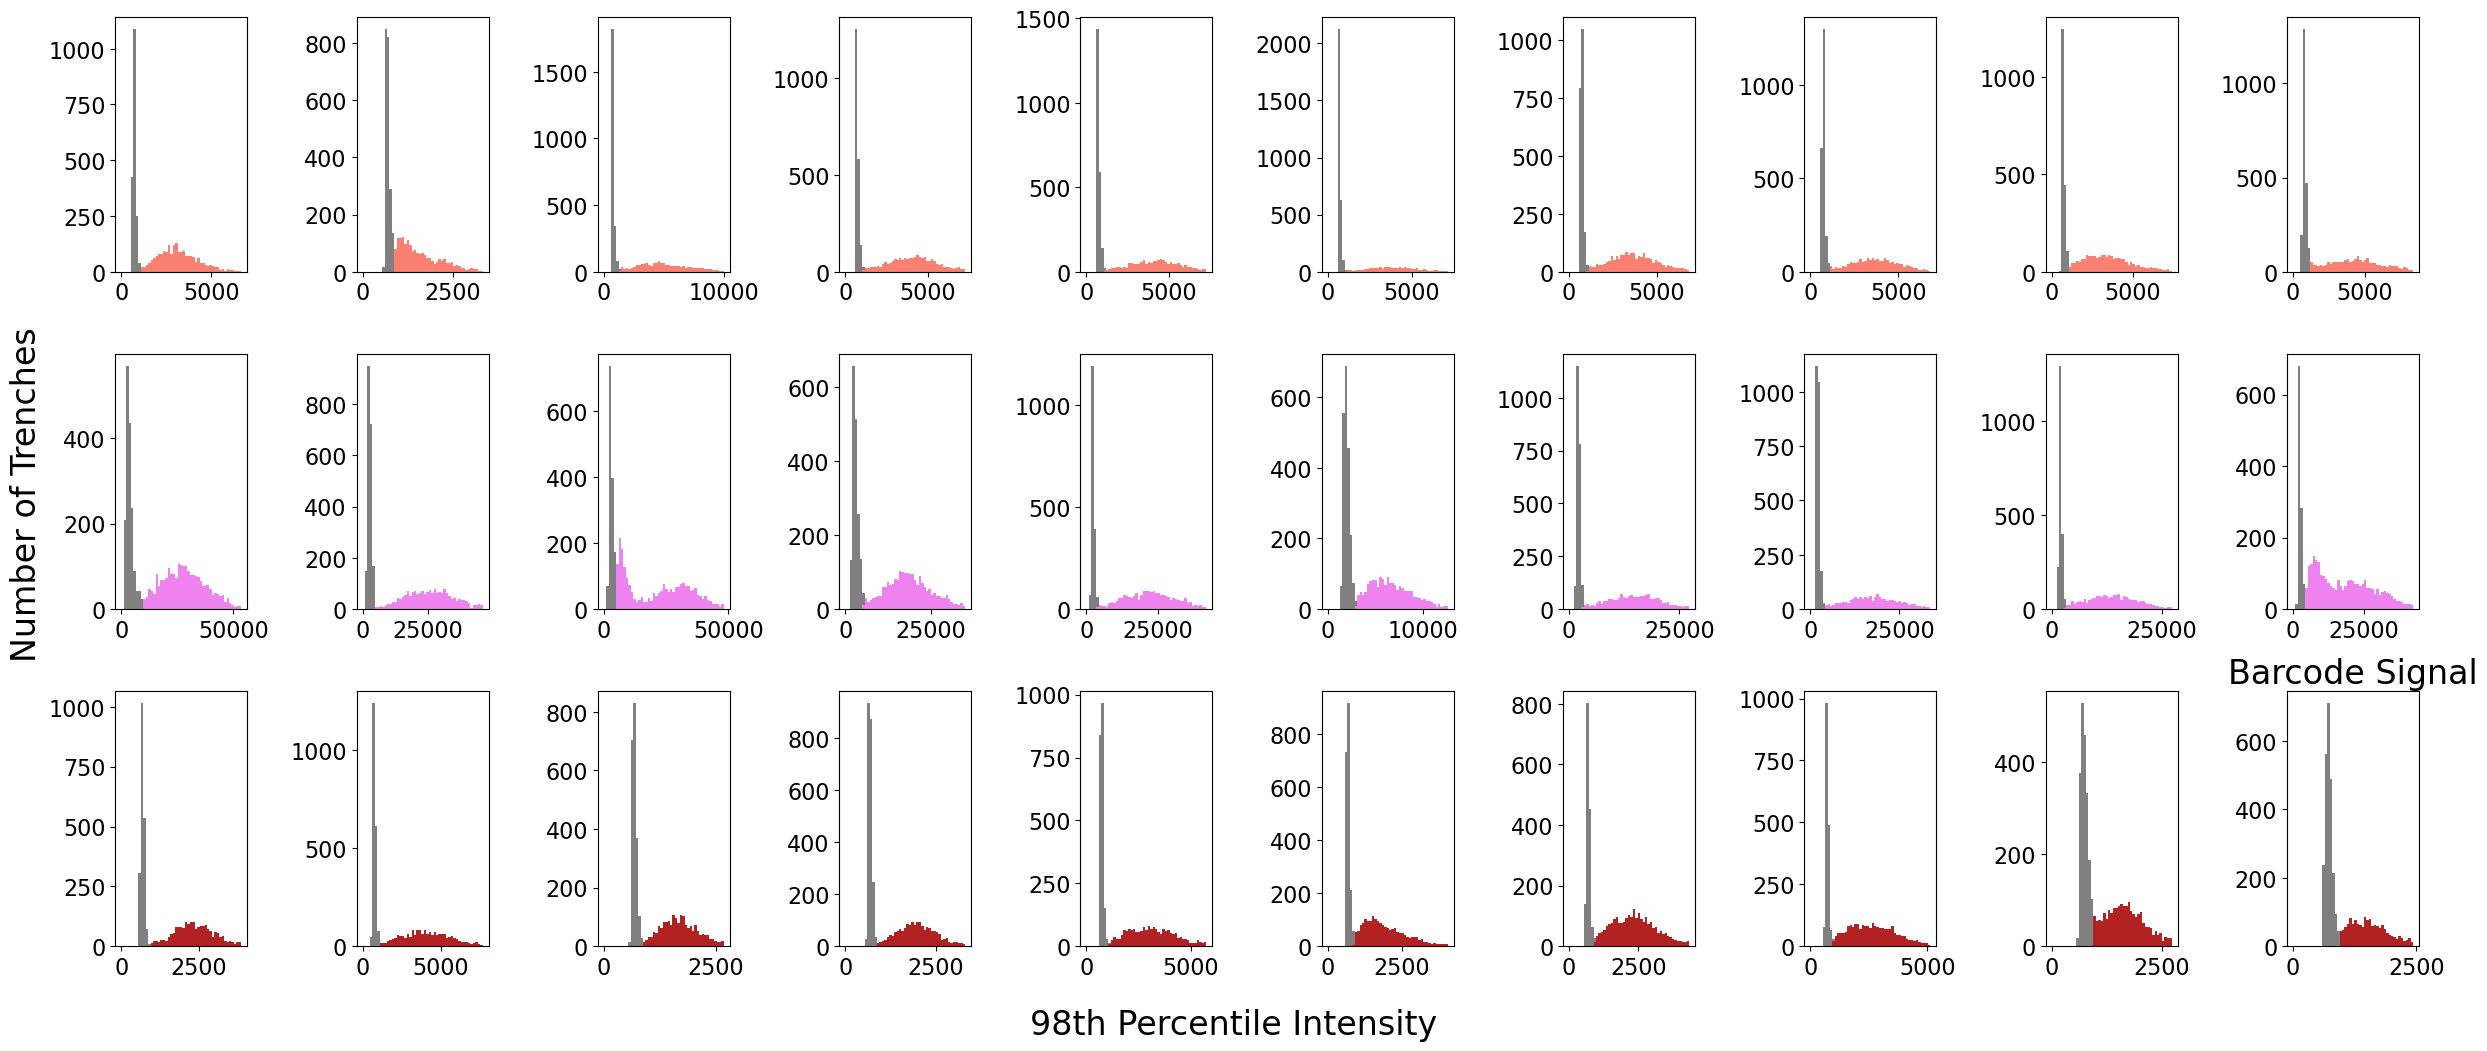

In [48]:
fish_test.export_bit_thresholds()

In [49]:
fish_test.output_barcode_df(dask_controller,'/home/de64/scratch/de64/sync_folder/2022-01-18_lDE20_Final_5/Barcodes/barcode_output_df.hdf5')

Getting Barcode df...


/home/cas77/paulssonlab/paulssonlab/src/paulssonlab/deaton/trenchripper/trenchripper/marlin.py:724: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  barcodes = trench_group.apply(lambda x: np.array(list(itertools.chain.from_iterable([x[channel].tolist()\


Getting Nanopore df...
Merging...


/home/cas77/mambaforge/envs/crispri/lib/python3.10/site-packages/dask/array/routines.py:446: PerformanceWarning: Increasing number of chunks by factor of 13
  out = blockwise(
/home/cas77/mambaforge/envs/crispri/lib/python3.10/site-packages/dask/array/routines.py:446: PerformanceWarning: Increasing number of chunks by factor of 13
  out = blockwise(
/home/cas77/mambaforge/envs/crispri/lib/python3.10/site-packages/zarr/creation.py:241: UserWarning: ignoring keyword argument 'inline_array'
  warn('ignoring keyword argument %r' % k)
/home/cas77/paulssonlab/paulssonlab/src/paulssonlab/deaton/trenchripper/trenchripper/utils.py:86: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['Barcode Signal', 'Barcode', 'consensus', 'reference', 'cigar',
       'aligned_cons', 'split_ref', 'split_align', 'hamm_ref', 'UMI', 'sgRNA',
       'Gene', 'Strand', 'Target Sequence

In [50]:
dask_controller.shutdown()

Done.


2023-01-17 09:00:03,217 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
